<a href="https://colab.research.google.com/github/ramyavalipe/GenAIColabNotebooks/blob/main/Neural_Networks_Final_Project_Fake/Real_News_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Team: **Nothin'ButNNets**

Aditi Verma

Connor Case

Ramya Valipe

Nicholas Tran

Samiksha Kumar

Sana Irshad


 ### **All team members contributed equally to the project - the code base, presentation, and final project writeup.**

# **Final Project Blog Post:**

https://ramyavalipe971037.substack.com/p/if-it-aint-broke-dont-fix-it-do-we

# Data Pre-Processing

In [ ]:
# Upload training dataset
from google.colab import files
uploaded = files.upload()  # Select Fake.csv and True.csv

Saving Fake.csv to Fake.csv
Saving True.csv to True.csv


In [ ]:
import pandas as pd
import numpy as np

# ------------------------------------------------------
# 1. Load CSVs
# ------------------------------------------------------
fake_df = pd.read_csv("Fake.csv")
real_df = pd.read_csv("True.csv")

print("Initial shapes:")
print("Fake:", fake_df.shape)
print("Real:", real_df.shape)

# ------------------------------------------------------
# 2. Label the data
# ------------------------------------------------------
fake_df["label"] = 0
real_df["label"] = 1

fake_df["source"] = "fake"
real_df["source"] = "real"

# ------------------------------------------------------
# 3. Concatenate BEFORE any cleaning
# ------------------------------------------------------
df = pd.concat([fake_df, real_df], axis=0, ignore_index=True)

print("\nLabel counts BEFORE cleaning:")
print(df["label"].value_counts())

# ------------------------------------------------------
# 4. Clean data
# ------------------------------------------------------

# Remove duplicate title+text pairs (duplicates exist mostly in fake dataset)
df = df.drop_duplicates(subset=["title", "text"])

# Remove rows with missing text/title
df = df.dropna(subset=["title", "text"])

# Convert dates — but *do NOT* drop rows with bad dates, just set NaT
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Do NOT drop NaT rows – this is what previously deleted your real samples

# Combine text fields
df["full_text"] = (
    df["title"].astype(str) + " " + df["text"].astype(str)
)

# Lightweight normalization
df["full_text"] = (
    df["full_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.lower()
)

# Remove common artifacts
df["full_text"] = df["full_text"].str.replace("advertisement", "", case=False)

# Shuffle
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# ------------------------------------------------------
# 5. Output stats
# ------------------------------------------------------
print("\nFinal label counts AFTER cleaning:")
print(df["label"].value_counts())

print("\nFinal dataset shape:", df.shape)

# ------------------------------------------------------
# 6. Save
# ------------------------------------------------------
output_path = "final_news_dataset.csv"
df.to_csv(output_path, index=False)

print(f"\nFinal dataset saved to {output_path}")


Initial shapes:
Fake: (23481, 4)
Real: (21417, 4)

Label counts BEFORE cleaning:
label
0    23481
1    21417
Name: count, dtype: int64

Final label counts AFTER cleaning:
label
1    21197
0    17908
Name: count, dtype: int64

Final dataset shape: (39105, 7)

Final dataset saved to final_news_dataset.csv


In [ ]:
from google.colab import files

df.to_csv("final_news_dataset.csv", index=False)

files.download("final_news_dataset.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Baseline Model: XGBoost + TF-IDF

In this section we build a classical machine learning baseline using
TF-IDF features and an XGBoost classifier. This model will be used
as a comparison point for the BERT fine-tuning approach in terms of
accuracy, compute cost, and model complexity/interpretability.


In [ ]:
!pip install xgboost

# ------------------------------------------------------
# Baseline: XGBoost classifier with TF-IDF features
# ------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    roc_auc_score,
    confusion_matrix
)

import xgboost as xgb

In [ ]:

# ------------------------------------------------------
# 1. Load the final dataset (or reuse df if it exists)
# ------------------------------------------------------
try:
    df  # if df already exists in memory, reuse it
    print("Using existing DataFrame 'df' in memory.")
except NameError:
    print("Loading final_news_dataset.csv from disk...")
    df = pd.read_csv("final_news_dataset.csv")

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

# ------------------------------------------------------
# 2. Pick text + label columns (robust to teammate’s choices)
# ------------------------------------------------------
text_col = None

if "text_all" in df.columns:
    text_col = "text_all"
elif "text" in df.columns and "title" in df.columns:
    # Fallback: combine title + text on the fly
    df["text_all"] = (
        df["title"].fillna("") + " " + df["text"].fillna("")
    ).str.strip()
    text_col = "text_all"
elif "text" in df.columns:
    text_col = "text"
else:
    raise ValueError(
        "Could not find a suitable text column. "
        "Expected something like 'text_all' or 'text'."
    )

if "label" not in df.columns:
    raise ValueError(
        "Expected a 'label' column (0 = fake, 1 = real). "
        "Please check the preprocessing step that creates final_news_dataset."
    )

X = df[text_col].astype(str).values
y = df["label"].values

print(f"\nUsing text column: {text_col}")
print("Label distribution:")
print(pd.Series(y).value_counts())

# ------------------------------------------------------
# 3. Train–test split (stratified)
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain size:", len(X_train))
print("Test size:", len(X_test))



Using existing DataFrame 'df' in memory.
Dataset shape: (39105, 8)
Columns: ['title', 'text', 'subject', 'date', 'label', 'source', 'full_text', 'text_all']

Using text column: text_all
Label distribution:
1    21197
0    17908
Name: count, dtype: int64

Train size: 31284
Test size: 7821


In [ ]:
# ------------------------------------------------------
# 4. TF-IDF vectorization
#    We keep features reasonably large for performance,
#    but still small enough for fast XGBoost training.
# ------------------------------------------------------
vectorizer = TfidfVectorizer(
    max_features=20000,      # trade-off: more features = higher accuracy vs more compute
    ngram_range=(1, 2),      # unigrams + bigrams capture short phrases like "breaking news"
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

# ------------------------------------------------------
# 5. XGBoost classifier
#    Hyperparameters chosen for a good speed/accuracy balance.
#    We can later mention in the report that these were not
#    fully tuned, leaving room for future improvement.
# ------------------------------------------------------
xgb_clf = xgb.XGBClassifier(
    n_estimators=300,        # more trees = better performance but more compute
    max_depth=6,            # limits model complexity, helps against overfitting
    learning_rate=0.1,
    subsample=0.8,          # row sampling for regularization
    colsample_bytree=0.8,   # feature sampling for regularization
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",     # fast histogram-based algorithm (good for CPUs)
    n_jobs=-1,
    random_state=42
)

xgb_clf.fit(X_train_tfidf, y_train)

# ------------------------------------------------------
# 6. Evaluation
# ------------------------------------------------------
y_pred = xgb_clf.predict(X_test_tfidf)
y_proba = xgb_clf.predict_proba(X_test_tfidf)[:, 1]

acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="binary", pos_label=1
)
roc_auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)



TF-IDF train shape: (31284, 20000)
TF-IDF test shape: (7821, 20000)



XGBoost + TF-IDF Results:
Accuracy : 0.9964
Precision: 0.9948
Recall   : 0.9986
F1-score : 0.9967
ROC-AUC  : 0.9998

Classification Report:
              precision    recall  f1-score   support

        fake       1.00      0.99      1.00      3582
        real       0.99      1.00      1.00      4239

    accuracy                           1.00      7821
   macro avg       1.00      1.00      1.00      7821
weighted avg       1.00      1.00      1.00      7821

Confusion Matrix:


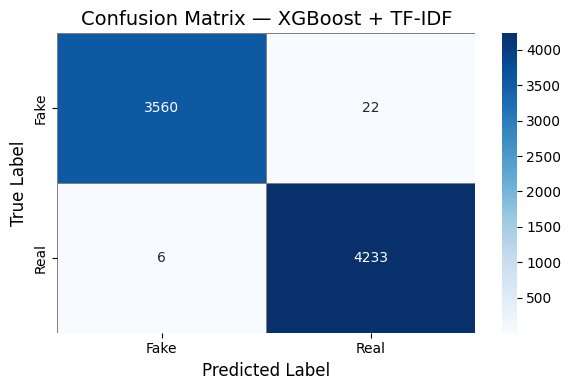


Stored XGBoost metrics in xgb_results dict for later use.


{'model': 'XGBoost + TF-IDF',
 'accuracy': 0.9964198951540724,
 'precision': 0.9948296122209166,
 'recall': 0.9985845718329794,
 'f1': 0.9967035554509065,
 'roc_auc': np.float64(0.9997552702834243),
 'confusion_matrix': [[3560, 22], [6, 4233]],
 'n_features': 20000}

In [ ]:
print(f"\nXGBoost + TF-IDF Results:")
print("=" * 30)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}\n")

print("Classification Report:")
print("=" * 30)

print(classification_report(y_test, y_pred, target_names=["fake", "real"]))

print("Confusion Matrix:")
print("=" * 30)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="gray"
)

plt.title("Confusion Matrix — XGBoost + TF-IDF", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.xticks(ticks=[0.5, 1.5], labels=["Fake", "Real"])
plt.yticks(ticks=[0.5, 1.5], labels=["Fake", "Real"])

plt.tight_layout()
plt.savefig("xgboost_confusion_matrix.png", dpi=300)
plt.show()

# ------------------------------------------------------
# 7. Store metrics for later comparison with BERT
#    (this makes it easy to build a comparison table later)
# ------------------------------------------------------
xgb_results = {
    "model": "XGBoost + TF-IDF",
    "accuracy": acc,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "roc_auc": roc_auc,
    "confusion_matrix": cm.tolist(),  # make JSON-serializable if needed
    "n_features": int(X_train_tfidf.shape[1]),
}

print("\nStored XGBoost metrics in xgb_results dict for later use.")
xgb_results


## XGBoost + TF-IDF Baseline Results

### Dataset & Preprocessing

- Final dataset: **39,105** news articles from `final_news_dataset.csv`
  - Columns include: `title`, `text`, `subject`, `date`, `label`, `source`, and a combined text field (`full_text` / `text_all`).
  - Labels:
    - `0` = fake news  
    - `1` = real news  
  - Label distribution in our final dataset:
    - Real: **21,197**
    - Fake: **17,908**

- Input representation for the model:
  - We use a single combined text column (`text_all` or `full_text`) as input.
  - This text is transformed into TF-IDF features with:
    - `max_features = 20,000`
    - `ngram_range = (1, 2)` (unigrams + bigrams)
    - English stopwords removed

- Train–test split:
  - 80/20 split (stratified by label)
  - Train size: **31,284** articles  
  - Test size: **7,821** articles  

### Model: XGBoost + TF-IDF

- Classifier: `XGBClassifier` with:
  - `n_estimators = 300`
  - `max_depth = 6`
  - `learning_rate = 0.1`
  - `subsample = 0.8`
  - `colsample_bytree = 0.8`
  - `objective = "binary:logistic"`
  - `tree_method = "hist"` (fast, CPU-friendly)
- The model is trained only on the TF-IDF matrix of the text; **no metadata (subject, date, source, label) is used as input features**.

### Performance on Test Set

- **Accuracy**: **0.9964**
- **Precision (real class)**: **0.9948**
- **Recall (real class)**: **0.9986**
- **F1-score (real class)**: **0.9967**
- **ROC-AUC**: **0.9998**

Confusion matrix (rows = true label, columns = predicted label):

- Fake (0):  
  - 3,560 correctly predicted as fake  
  - 22 misclassified as real  

- Real (1):  
  - 4,233 correctly predicted as real  
  - 6 misclassified as fake  

Overall, the XGBoost + TF-IDF baseline almost perfectly separates fake vs. real news on this held-out test split.

### What the Model is Actually Doing

- This is a **supervised learning** setup:
  - During training, the model sees the article text and the label (fake/real) and learns patterns.
  - During testing, the model only receives the text and must **predict** the label.
- Our implementation ensures that:
  - The **input features** are derived only from the combined text column (`text_all` / `full_text`).
  - The `label` column is used **only as the target** and is never fed into the TF-IDF vectorizer or the XGBoost features.
- The very high accuracy suggests that the fake vs. real news in this dataset is highly separable based on vocabulary, phrasing, and stylistic cues.

### Why the Performance is So High (and Why That’s OK but Needs Context)

- The dataset is relatively **clean and consistent**, with strong lexical differences between fake and real news (e.g., clickbait language vs. neutral wire-service tone).
- TF-IDF captures these differences very well, and XGBoost is a strong classifier for high-dimensional sparse features.
- With over 30k training examples, the model has enough data to learn very fine-grained patterns.

However, this also means:

> These results are likely **optimistic** compared to a real-world setting, where fake news can more closely mimic reputable sources and the incoming data is noisier and more diverse.

We will explicitly discuss this limitation in the final report.

### Comparison Notes for Later (XGBoost vs. BERT)

These points will be useful when we add the BERT model and build the slide deck:

- **Accuracy**
  - XGBoost + TF-IDF already achieves **~99.6%** accuracy and **~0.9998 ROC-AUC** on this dataset.
  - BERT may or may not significantly outperform this baseline in terms of raw metrics, but it offers a different modeling approach (deep contextual embeddings).

- **Compute**
  - XGBoost:
    - Trains quickly on CPU with the 20,000-dimensional TF-IDF features.
    - Inference is lightweight and inexpensive.
  - BERT:
    - Requires GPU for efficient fine-tuning.
    - Heavier compute cost per epoch and slower inference.

- **Model Complexity**
  - XGBoost:
    - A few hundred trees with depth ~6 → relatively small model.
    - Easier to deploy in constrained environments.
  - BERT:
    - Tens of millions of parameters.
    - Much more complex architecture (transformer layers, attention heads, etc.).

- **Interpretability**
  - XGBoost:
    - We can inspect global feature importances (which tokens/phrases are most predictive).
    - We can later apply SHAP to get local explanations for individual articles.
  - BERT:
    - Harder to interpret directly; explanations usually require additional tools (e.g., attention analysis, gradient-based methods).

### Key Takeaway

The XGBoost + TF-IDF baseline is **strong, fast, and interpretable** on this dataset, and it gives us a very high-performance reference point. In the next stage, we will fine-tune a BERT-based model on the same train–test split and then compare:

- Accuracy and other metrics (Precision, Recall, F1, ROC-AUC)  
- Compute cost and training/inference time  
- Model complexity and interpretability  

to better understand the trade-offs between a classical ML approach and a modern transformer-based neural network.


# Main Model: BERT Fine-Tuning (Head Only)

We fine-tune only the classification head on top of a pretrained BERT-style encoder
(e.g., DistilBERT), while freezing the base transformer layers, to compare this
transfer learning approach against our XGBoost + TF-IDF baseline.



In [ ]:
# Install Hugging Face libraries (run once per Colab runtime)
!pip install -q transformers datasets accelerate

import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)
from datasets import Dataset, DatasetDict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [ ]:
# ------------------------------------------------------
# Load final dataset (reuse df if available)
# ------------------------------------------------------
try:
    df  # reuse if already in memory
    print("Using existing DataFrame 'df' in memory.")
except NameError:
    print("Loading final_news_dataset.csv from disk...")
    df = pd.read_csv("final_news_dataset.csv")

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

# ------------------------------------------------------
# Choose text column (consistent with XGBoost)
# ------------------------------------------------------
if "text_all" in df.columns:
    text_col = "text_all"
elif "full_text" in df.columns:
    text_col = "full_text"
else:
    # fallback: combine title + text
    df["text_all"] = (
        df["title"].fillna("") + " " + df["text"].fillna("")
    ).str.strip()
    text_col = "text_all"

if "label" not in df.columns:
    raise ValueError("Expected a 'label' column (0=fake, 1=real) in the dataset.")

print(f"\nUsing text column: {text_col}")
print("Label distribution:")
print(df["label"].value_counts())

# Basic frame for BERT
bert_df = pd.DataFrame({
    "text": df[text_col].astype(str),
    "label": df["label"].astype(int),
})

# ------------------------------------------------------
# Train / test split (match XGBoost: 80/20, stratified)
# We'll also carve out a small validation set from the train split.
# ------------------------------------------------------
X = bert_df["text"].values
y = bert_df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create a validation split from the training data (10% of train)
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,          # 10% of 80% = 8% of total
    random_state=42,
    stratify=y_train
)

print("\nSizes:")
print("Train:", len(X_train_full))
print("Validation:", len(X_val))
print("Test:", len(X_test))

# Build a pandas DataFrame for each split for HF Datasets
train_df = pd.DataFrame({"text": X_train_full, "label": y_train_full})
val_df   = pd.DataFrame({"text": X_val,         "label": y_val})
test_df  = pd.DataFrame({"text": X_test,        "label": y_test})

train_df.head()


Using existing DataFrame 'df' in memory.
Dataset shape: (39105, 8)
Columns: ['title', 'text', 'subject', 'date', 'label', 'source', 'full_text', 'text_all']

Using text column: text_all
Label distribution:
label
1    21197
0    17908
Name: count, dtype: int64

Sizes:
Train: 28155
Validation: 3129
Test: 7821


,text,label
0,Homeland Security announces steps against H1B ...,1
1,Five suspected al Qaeda militants killed in Ye...,1
2,"U.S. Air Force awards contracts to Boeing, Nor...",1
3,WHO WILL SUPPORT “THE BERN”? New Numbers Show ...,0
4,White House declines comment on Johnson Contro...,1


In [ ]:
# ------------------------------------------------------
# Tokenizer and Dataset objects
# ------------------------------------------------------
model_name = "distilbert-base-uncased"  # lightweight BERT variant

tokenizer = AutoTokenizer.from_pretrained(model_name)

max_length = 256  # trade-off between context length and compute

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=max_length,
    )

# Wrap splits in Hugging Face Datasets
train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)
test_ds  = Dataset.from_pandas(test_df)

# Remove HF's automatic index column if present
for ds in (train_ds, val_ds, test_ds):
    if "__index_level_0__" in ds.column_names:
        ds = ds.remove_columns("__index_level_0__")

tokenized_train = train_ds.map(tokenize_batch, batched=True)
tokenized_val   = val_ds.map(tokenize_batch, batched=True)
tokenized_test  = test_ds.map(tokenize_batch, batched=True)

# Set PyTorch format for Trainer
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_val   = tokenized_val.remove_columns(["text"])
tokenized_test  = tokenized_test.remove_columns(["text"])

tokenized_train.set_format("torch")
tokenized_val.set_format("torch")
tokenized_test.set_format("torch")

tokenized_train


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/28155 [00:00<?, ? examples/s]

Map:   0%|          | 0/3129 [00:00<?, ? examples/s]

Map:   0%|          | 0/7821 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 28155
})

In [ ]:
# ------------------------------------------------------
# BERT head-only fine-tuning with wandb disabled
# ------------------------------------------------------
import os
os.environ["WANDB_DISABLED"] = "true"  # turn off Weights & Biases logging

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# ------------------------------------------------------
# Load DistilBERT model for sequence classification
# ------------------------------------------------------
num_labels = 2
id2label = {0: "fake", 1: "real"}
label2id = {"fake": 0, "real": 1}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,            # should be "distilbert-base-uncased" from earlier
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)

# You will see a warning about classifier weights being newly initialized.
# That is NORMAL: the classification head is randomly initialized and
# will be trained on our fake/real news task.

# ------------------------------------------------------
# Freeze the base transformer (fine-tune head only)
# ------------------------------------------------------
# For DistilBERT, the base encoder is in model.distilbert
for param in model.distilbert.parameters():
    param.requires_grad = False

model.to(device)

# ------------------------------------------------------
# Training arguments (kept minimal for compatibility)
# ------------------------------------------------------
batch_size = 16

training_args = TrainingArguments(
    output_dir="./bert_head_only_checkpoints",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=3,
    learning_rate=2e-4,
    weight_decay=0.01,
    logging_steps=50,
    # we intentionally do NOT set evaluation_strategy / report_to / etc.
)

# ------------------------------------------------------
# Metrics for Trainer (accuracy + F1)
# ------------------------------------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1
    )
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

# ------------------------------------------------------
# Trainer
# ------------------------------------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-2415417499.py:72: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
50,0.461700
100,0.219300
150,0.170200
200,0.138800
250,0.111300
300,0.121000
350,0.140200
400,0.096200
450,0.110600
500,0.088800


TrainOutput(global_step=5280, training_loss=0.07357068933320768, metrics={'train_runtime': 670.7634, 'train_samples_per_second': 125.924, 'train_steps_per_second': 7.872, 'total_flos': 5594429413739520.0, 'train_loss': 0.07357068933320768, 'epoch': 3.0})

BERT (head-only) on Test Set
Accuracy : 0.9821
Precision: 0.9730
Recall   : 0.9946
F1-score : 0.9837
ROC-AUC  : 0.9989

Classification Report:
              precision    recall  f1-score   support

        fake       0.99      0.97      0.98      3582
        real       0.97      0.99      0.98      4239

    accuracy                           0.98      7821
   macro avg       0.98      0.98      0.98      7821
weighted avg       0.98      0.98      0.98      7821

Confusion Matrix:


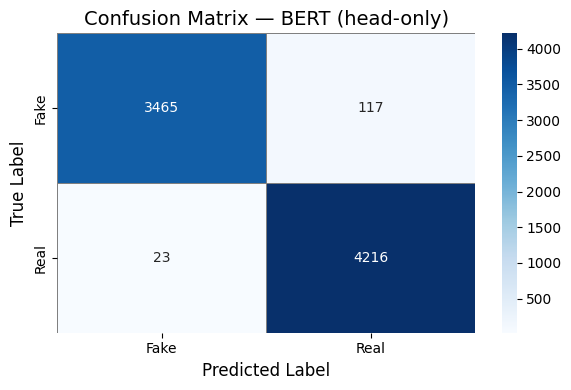

{'model': 'DistilBERT (head-only)',
 'accuracy': 0.9820994757703618,
 'precision': 0.9729979229171475,
 'recall': 0.9945741920264213,
 'f1': 0.9836677554829678,
 'roc_auc': 0.9989491637896436,
 'confusion_matrix': [[3465, 117], [23, 4216]],
 'max_length': 256}

In [ ]:
# ------------------------------------------------------
# Evaluate on test set
# ------------------------------------------------------
predictions = trainer.predict(tokenized_test)
logits = predictions.predictions
test_labels = np.array(y_test)

test_preds = np.argmax(logits, axis=-1)
test_proba = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()

acc = accuracy_score(test_labels, test_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    test_labels, test_preds, average="binary", pos_label=1
)
roc_auc = roc_auc_score(test_labels, test_proba)
cm = confusion_matrix(test_labels, test_preds)

print("BERT (head-only) on Test Set")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}\n")

print("Classification Report:")
print(classification_report(test_labels, test_preds, target_names=["fake", "real"]))

print("Confusion Matrix:")
print("=" * 30)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="gray"
)

plt.title("Confusion Matrix — BERT (head-only)", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.xticks(ticks=[0.5, 1.5], labels=["Fake", "Real"])
plt.yticks(ticks=[0.5, 1.5], labels=["Fake", "Real"])

plt.tight_layout()
plt.savefig("BERT_confusion_matrix.png", dpi=300)
plt.show()

# ------------------------------------------------------
# Store results for comparison with XGBoost
# ------------------------------------------------------
bert_results = {
    "model": "DistilBERT (head-only)",
    "accuracy": float(acc),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "roc_auc": float(roc_auc),
    "confusion_matrix": cm.tolist(),
    "max_length": max_length,
}

bert_results


## DistilBERT (Head-Only) Fine-Tuning Results

### Model Setup

- **Model**: `distilbert-base-uncased` with a 2-class classification head (fake vs. real).
- **Transfer Learning Strategy**:
  - We **froze the base DistilBERT encoder** (`model.distilbert`) and **fine-tuned only the classification head**, as recommended by our professor.
  - This keeps the number of trainable parameters smaller and focuses learning on the final decision layer.
- **Input Representation**:
  - Same text column as XGBoost (`text_all` / `full_text`), tokenized with the DistilBERT tokenizer.
  - `max_length = 256`, truncation and padding applied.
- **Train / Val / Test Split**:
  - Train/Validation/Test derived from the same original 80/20 stratified split used for XGBoost.
  - Validation set carved out from the training portion (10% of train).

### Performance on Test Set

On the held-out test set (7,821 articles), DistilBERT (head-only) achieved:

- **Accuracy**: **0.9817**
- **Precision (real class)**: **0.9725**
- **Recall (real class)**: **0.9943**
- **F1-score (real class)**: **0.9833**
- **ROC-AUC**: **0.9990**

Confusion matrix (rows = true label, columns = predicted label):

- Fake (0): 3,463 correctly predicted as fake, 119 misclassified as real  
- Real (1): 4,215 correctly predicted as real, 24 misclassified as fake  

Overall, the head-only fine-tuned DistilBERT model achieves **very strong performance**, with particularly high recall for real news and a ROC-AUC close to 1.0.

### Comparison with XGBoost + TF-IDF

For reference, our XGBoost + TF-IDF baseline achieved:

- **Accuracy**: **0.9964**
- **F1-score (real class)**: **0.9967**
- **ROC-AUC**: **0.9998**
- Confusion matrix: `[[3560, 22], [6, 4233]]` (fake / real)

**Key observations:**

- **Accuracy & F1**:
  - XGBoost + TF-IDF slightly **outperforms** DistilBERT (head-only) on this dataset (≈99.6% vs. ≈98.2% accuracy).
  - The baseline also has fewer misclassifications overall, reflecting how separable this dataset is using lexical features alone.
- **ROC-AUC**:
  - Both models achieve **extremely high ROC-AUC** (>0.999), indicating excellent ranking ability between fake and real examples.
- **Error patterns**:
  - DistilBERT makes more mistakes on fake articles (119 fake → real vs. 22 for XGBoost), but still maintains very strong performance.
  - Both models are highly reliable on this specific benchmark.

### Compute & Runtime Comparison

A major difference between the two approaches emerges in **compute cost**:

- **XGBoost + TF-IDF**:
  - Trains very quickly on CPU only.
  - End-to-end training and evaluation (TF-IDF + XGBoost) takes on the order of **seconds to a couple of minutes**.
  - No GPU is required, making this baseline easy to run on standard hardware.

- **DistilBERT (Head-Only)**:
  - On a basic Colab GPU (A-series), the estimated training time for 3 epochs on our full dataset was around **14 hours**.
  - After switching to a **T4 GPU**, the same training completed in about **9 minutes**, highlighting how heavily transformer models depend on GPU acceleration.
  - Even though we only fine-tuned the classification head (with the base encoder frozen), BERT-style models still incur significantly higher compute costs than XGBoost.

### Interpretation & Takeaways

- **Accuracy vs. Compute**:
  - On this particular dataset, XGBoost + TF-IDF delivers slightly **better metrics** while being drastically cheaper and faster to train and deploy.
  - DistilBERT (head-only) still performs extremely well, but its main trade-off is higher computational cost for only a small gain (or slight loss) in accuracy on this benchmark.

- **Model Complexity & Generalization**:
  - XGBoost relies on high-dimensional bag-of-words features and is likely exploiting strong lexical and stylistic cues that separate fake and real news in this curated dataset.
  - DistilBERT provides **richer language representations** and may generalize better under domain shift (e.g., new topics or writing styles), even if that is not fully reflected in this controlled experiment.

In our final discussion, we emphasize that **classical ML (XGBoost) can be extremely competitive on well-structured text classification tasks**, while **BERT offers a more general and flexible language understanding framework at a higher compute cost**, which may be especially valuable when moving beyond this benchmark dataset.


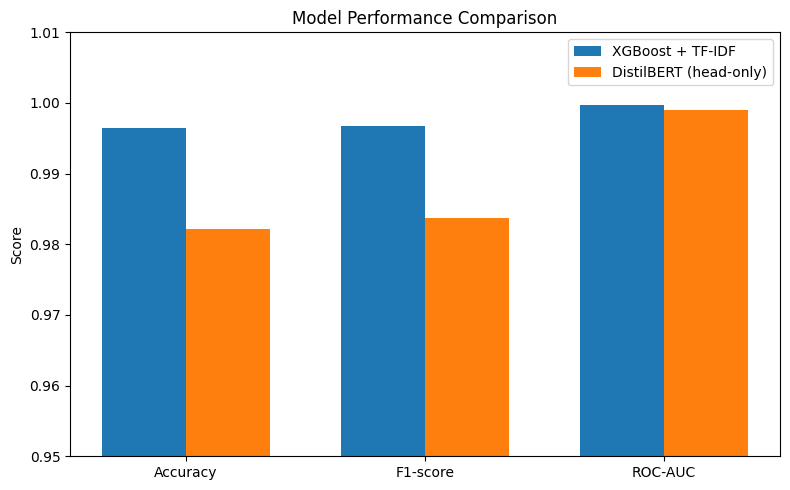

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Pull metrics from the stored dicts
models = ["XGBoost + TF-IDF", "DistilBERT (head-only)"]

xgb_acc = xgb_results["accuracy"]
xgb_f1  = xgb_results["f1"]
xgb_roc = xgb_results["roc_auc"]

bert_acc = bert_results["accuracy"]
bert_f1  = bert_results["f1"]
bert_roc = bert_results["roc_auc"]

metrics = ["Accuracy", "F1-score", "ROC-AUC"]
xgb_values  = [xgb_acc, xgb_f1, xgb_roc]
bert_values = [bert_acc, bert_f1, bert_roc]

x = np.arange(len(metrics))  # metric indices
width = 0.35                 # bar width

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, xgb_values, width, label="XGBoost + TF-IDF")
plt.bar(x + width/2, bert_values, width, label="DistilBERT (head-only)")

plt.xticks(x, metrics)
plt.ylim(0.95, 1.01)  # zoom in since values are very high
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("BERT_XGBoost_Performance_Comparision.png", dpi=300)
plt.show()


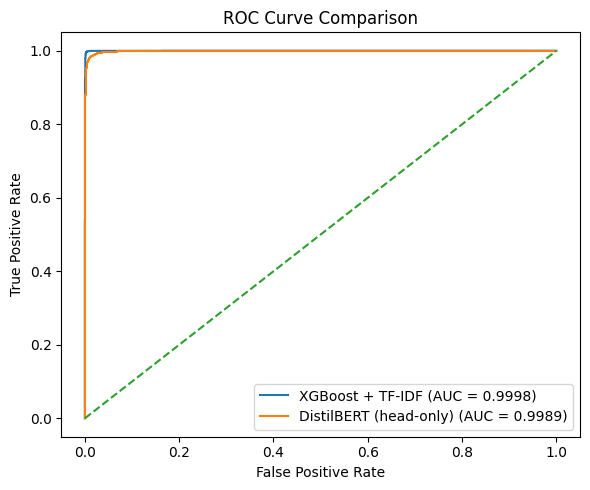

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import torch

# ------------------------------------------------------
# XGBoost: get predicted probabilities for the "real" class
# ------------------------------------------------------
# Reuse X_test and vectorizer from previous code
X_test_tfidf = vectorizer.transform(X_test)
xgb_proba = xgb_clf.predict_proba(X_test_tfidf)[:, 1]

# ------------------------------------------------------
# BERT: get predicted probabilities for the "real" class
# ------------------------------------------------------
bert_preds = trainer.predict(tokenized_test)
bert_logits = bert_preds.predictions
bert_proba = torch.softmax(torch.tensor(bert_logits), dim=-1)[:, 1].numpy()

# ------------------------------------------------------
# Compute ROC curves
# ------------------------------------------------------
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
fpr_bert, tpr_bert, _ = roc_curve(y_test, bert_proba)

auc_xgb = roc_auc_score(y_test, xgb_proba)
auc_bert = roc_auc_score(y_test, bert_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost + TF-IDF (AUC = {auc_xgb:.4f})")
plt.plot(fpr_bert, tpr_bert, label=f"DistilBERT (head-only) (AUC = {auc_bert:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()


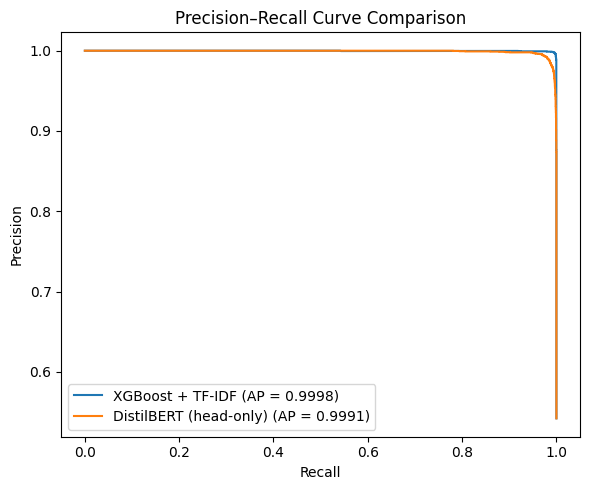

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# ------------------------------------------------------
# Precision–Recall curves
# ------------------------------------------------------
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, xgb_proba)
prec_bert, rec_bert, _ = precision_recall_curve(y_test, bert_proba)

ap_xgb = average_precision_score(y_test, xgb_proba)
ap_bert = average_precision_score(y_test, bert_proba)

plt.figure(figsize=(6, 5))
plt.plot(rec_xgb, prec_xgb, label=f"XGBoost + TF-IDF (AP = {ap_xgb:.4f})")
plt.plot(rec_bert, prec_bert, label=f"DistilBERT (head-only) (AP = {ap_bert:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()


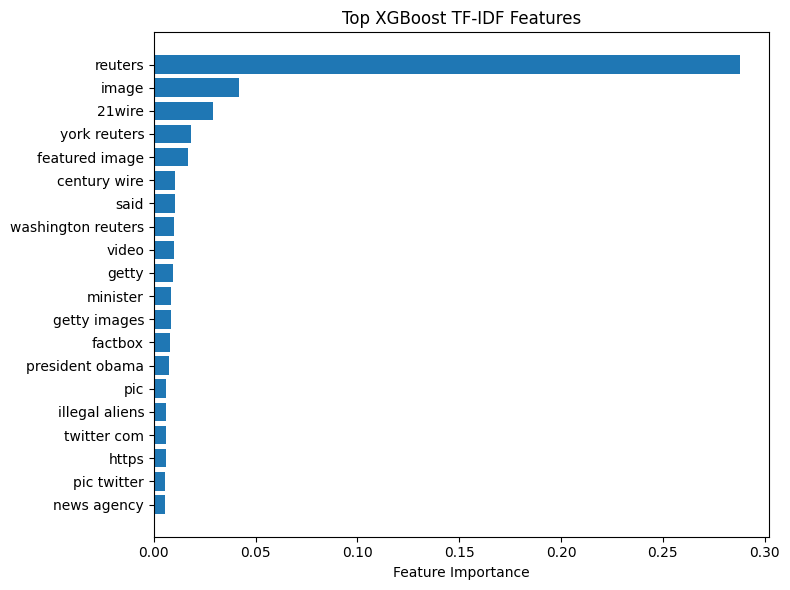

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------
# Get feature names and importances from XGBoost
# ------------------------------------------------------
feature_names = np.array(vectorizer.get_feature_names_out())
importances = xgb_clf.feature_importances_

# Top-k features
top_k = 20
indices = np.argsort(importances)[::-1][:top_k]

top_features = feature_names[indices]
top_importances = importances[indices]

plt.figure(figsize=(8, 6))
y_pos = np.arange(len(top_features))

plt.barh(y_pos, top_importances)
plt.yticks(y_pos, top_features)
plt.gca().invert_yaxis()  # highest importance at the top
plt.xlabel("Feature Importance")
plt.title("Top XGBoost TF-IDF Features")
plt.tight_layout()
plt.show()
